Görüntü boyutu: torch.Size([1, 28, 28])
Etiket: 5


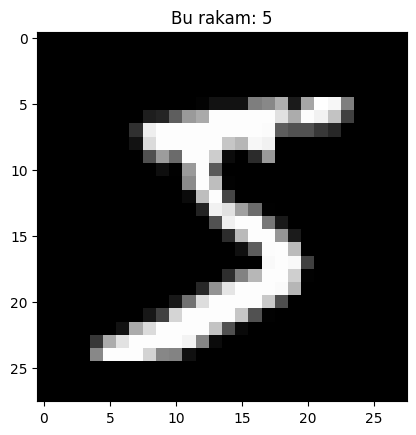

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

image, label = train_dataset[0]
print(f"Görüntü boyutu: {image.shape}")
print(f"Etiket: {label}")

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Bu rakam: {label}")
plt.show()

In [4]:
import torch.nn as nn

conv_layer = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3)

print(conv_layer)

Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))


In [5]:
image_batch = image.unsqueeze(0)
output = conv_layer(image_batch)

print(f"Girdi boyutu: {image.shape}")
print(f"Çıktı boyutu: {output.shape}")

Girdi boyutu: torch.Size([1, 28, 28])
Çıktı boyutu: torch.Size([1, 8, 26, 26])


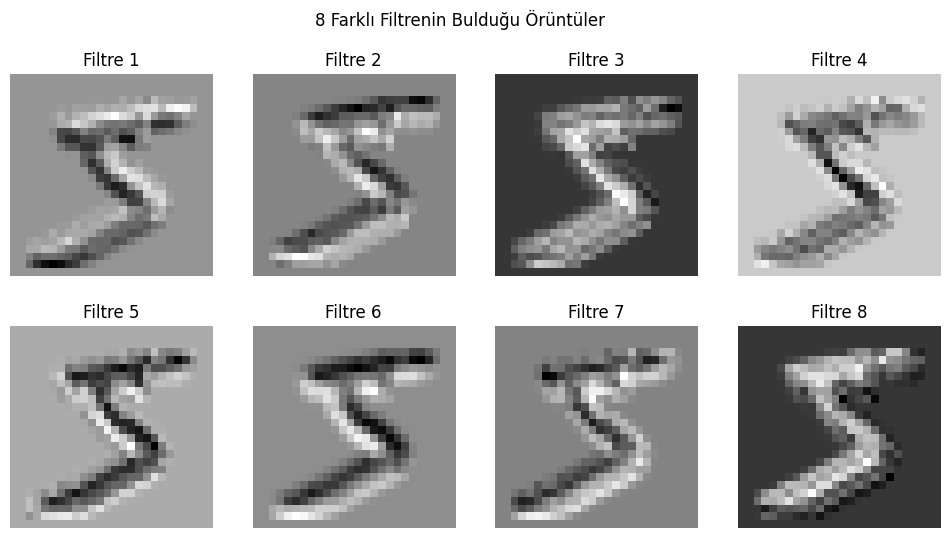

In [6]:
output_detached = output.detach()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(output_detached[0, i], cmap='gray')
    ax.set_title(f'Filtre {i+1}')
    ax.axis('off')

plt.suptitle('8 Farklı Filtrenin Bulduğu Örüntüler')
plt.show()

In [7]:
pool_layer = nn.MaxPool2d(kernel_size=2, stride=2)

pooled_output = pool_layer(output)

print(f"Pooling öncesi boyut: {output.shape}")
print(f"Pooling sonrası boyut: {pooled_output.shape}")

Pooling öncesi boyut: torch.Size([1, 8, 26, 26])
Pooling sonrası boyut: torch.Size([1, 8, 13, 13])


In [8]:
cnn_model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

print(cnn_model)

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=400, out_features=64, bias=True)
  (8): ReLU()
  (9): Linear(in_features=64, out_features=10, bias=True)
)


In [9]:
sample_output = cnn_model[:6](image_batch)
print(f"Flatten öncesi boyut: {sample_output.shape}")

Flatten öncesi boyut: torch.Size([1, 16, 5, 5])


In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

images, labels = next(iter(train_loader))
print(f"Bir batch'teki resim sayısı: {images.shape}")
print(f"Bir batch'teki etiket sayısı: {labels.shape}")

Bir batch'teki resim sayısı: torch.Size([64, 1, 28, 28])
Bir batch'teki etiket sayısı: torch.Size([64])


In [11]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

In [12]:
epochs = 3

for epoch in range(epochs):
    total_loss = 0
    for images, labels in train_loader:
        outputs = cnn_model(images)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Ortalama Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/3, Ortalama Loss: 0.3619
Epoch 2/3, Ortalama Loss: 0.1034
Epoch 3/3, Ortalama Loss: 0.0748


In [13]:
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

correct = 0
total = 0

cnn_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f"Test Doğruluk Oranı: {accuracy:.2%}")


Test Doğruluk Oranı: 98.15%


## 🖼️ İlk CNN Projesi - Özet

**Veri seti:** MNIST (el yazısı rakam tanıma, 0-9)
**Amaç:** Convolutional Neural Network (CNN) mantığını sıfırdan öğrenip, görüntü sınıflandırma modeli kurmak

**Model mimarisi:**
1 kanal (28x28) → Conv2d(8 filtre) → ReLU → MaxPool → Conv2d(16 filtre) → ReLU → MaxPool → Flatten → Linear(64) → ReLU → Linear(10 çıktı)

**Öğrendiğim yeni kavramlar:**
- Convolution (evrişim): küçük bir filtrenin resim üzerinde gezerek örüntü (kenar, köşe) araması
- Feature map (özellik haritası): bir filtrenin resimde bulduklarının görsel karşılığı
- in_channels / out_channels / kernel_size: bir Conv2d katmanının temel ayarları
- Pooling (MaxPool2d): boyutu küçültüp en güçlü sinyali koruma işlemi
- Flatten: convolution/pooling sonrası ızgarayı düz listeye çevirme
- DataLoader ve batch mantığı: veriyi küçük gruplar halinde işleme
- CrossEntropyLoss: çok sınıflı (10 kategori) sınıflandırma için kayıp fonksiyonu

**Sonuç:**
- 3 epoch'ta loss: 0.3619 → 0.1034 → 0.0748
- **Test doğruluk oranı: %98.15**

**Çıkardığım ders:** CNN, görüntüdeki komşuluk (piksel yakınlığı) bilgisini koruyarak çalıştığı için, düz bir sinir ağına göre çok daha hızlı ve güçlü öğrendi — sadece 3 epoch'ta %98'in üzerinde bir başarı elde etti.